# CRN Surrogate: Deterministic Mass-Action Experiment

End-to-end pipeline on Colab GPU using the refactored Hydra config system.

**What this does:**
1. Clones the repo and installs dependencies (including Hydra)
2. Generates a deterministic ODE dataset of random mass-action CRNs (2-3 species, 3-7 reactions)
3. Trains the encoder + NeuralDrift on deterministic trajectories
4. Evaluates on novel random topologies

**Why deterministic first?** ODE data generation is fast (no SSA), single trajectory per item (M=1),
and validates the full pipeline before scaling to stochastic systems.

In [4]:
# --- Colab setup ---
import subprocess, sys, os
from pathlib import Path

REPO_URL = "https://github.com/Mijan/CRN_Surrogate.git"
CLONE_DIR = Path("../../").resolve() #"/content/CRN_Surrogate"
SRC_DIR = CLONE_DIR/ "src"
BRANCH = "main"  # change if working on a feature branch

# if not os.path.exists(CLONE_DIR):
#     print("Cloning repo...")
#     subprocess.check_call(["git", "clone", "-q", "-b", BRANCH, REPO_URL, CLONE_DIR])
# else:
#     print(f"Using existing clone at {CLONE_DIR}")
#     subprocess.check_call(["git", "-C", CLONE_DIR, "pull", "-q"])
#
# os.chdir(CLONE_DIR)
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", "."])
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hydra-core", "omegaconf", "wandb"])
#
# sys.path.insert(0, CLONE_DIR)
# sys.path.insert(0, SRC_DIR)
# print("Setup complete.")

## W&B Authentication

Set `USE_WANDB = False` to skip logging entirely.

In [5]:
USE_WANDB = True

if USE_WANDB:
    import wandb
    wandb.login()

wandb: Currently logged in as: jan-mikelson (jan-mikelson-independent) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Configuration via Hydra

The experiment is defined by composing YAML config groups.
Here we load and inspect the deterministic experiment preset.

In [6]:
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from pathlib import Path

config_dir = str(Path(CLONE_DIR) / "experiments" / "configs")

with initialize_config_dir(version_base=None, config_dir=config_dir):
    cfg = compose(
        config_name="config",
        overrides=["experiment=mass_action_3s_det"],
    )

print(OmegaConf.to_yaml(cfg))

model:
  d_model: 128
  n_encoder_layers: 3
  d_hidden: 256
  n_sde_hidden_layers: 3
  d_protocol: 0
  context_dropout: 0.1
  mlp_dropout: 0.1
  max_n_species: 3
  max_n_reactions: 7
training:
  lr: 0.0003
  max_epochs: 1000
  batch_size: 1024
  n_trajectory_samples: 1
  dt: 0.1
  grad_clip_norm: 1.0
  scheduler_type: reduce_on_plateau
  val_every: 5
  checkpoint_every: 20
  num_workers: 0
  shuffle_train: true
  gpu_memory_fraction: 0.5
dataset:
  n_train: 30000
  n_val: 3000
  n_trajectories: 1
  t_max: 20.0
  n_time_points: 100
  initial_state_mean: 10.0
  initial_state_spread: 3.0
  topology:
    n_species_range:
    - 2
    - 3
    n_reactions_range:
    - 3
    - 7
    max_reactant_order: 2
    max_product_count: 2
  rate_constant_range:
  - 0.01
  - 10.0
solver:
  deterministic: true
  use_log1p: false
  clip_state: true
measurement:
  noise_mode: fixed
  noise_sharing: shared
  noise_init_eps: 5
  min_variance: 0.01
experiment_name: mass_action_3s_det
wandb_project: crn-surroga

### Inspect the resolved config

Key settings for the deterministic experiment:
- `solver.deterministic: true` selects `NeuralDrift` + `EulerODESolver` + `ODESimulator`
- `training.n_ssa_samples: 1` since there is only M=1 trajectory per item
- `dataset.n_ssa_trajectories: 1` matches
- `model.max_n_reactions: 7` for slightly larger topologies

In [ ]:
print(f"Experiment:     {cfg.experiment_name}")
print(f"Deterministic:  {cfg.solver.deterministic}")
print(f"Max species:    {cfg.model.max_n_species}")
print(f"Max reactions:  {cfg.model.max_n_reactions}")
print(f"d_model:        {cfg.model.d_model}")
print(f"d_hidden:       {cfg.model.d_hidden}")
print(f"Dropout:        context={cfg.model.context_dropout}, mlp={cfg.model.mlp_dropout}")
print(f"Train items:    {cfg.dataset.n_train}")
print(f"Val items:      {cfg.dataset.n_val}")
print(f"Batch size:     {cfg.training.batch_size}")
print(f"Max epochs:     {cfg.training.max_epochs}")
print(f"LR:             {cfg.training.lr}")
print(f"Scheduler:      {cfg.training.scheduler_type}")

You can override any value inline:
```python
cfg = compose(config_name="config", overrides=[
    "experiment=mass_action_3s_det",
    "training.max_epochs=100",
    "dataset.n_train=5000",
])
```

## Step 1: Generate Deterministic Dataset

Samples random mass-action CRNs, integrates the ODE, curates, and saves.
Much faster than SSA since there is no stochastic sampling.

In [ ]:
wandb_flag = "" if USE_WANDB else "no_wandb=true"

!cd {CLONE_DIR} && python -u experiments/scripts/generate_dataset.py \
    experiment=mass_action_3s_det \
    generation.checkpoint_every=500 \
    {wandb_flag}

### Quick data inspection

In [ ]:
import json
import torch

dataset_dir = Path(CLONE_DIR) / "experiments" / "datasets"
meta_path = dataset_dir / f"{cfg.experiment_name}_meta.json"
meta = json.loads(meta_path.read_text())

print(f"Train items: {meta['n_train']}")
print(f"Val items:   {meta['n_val']}")
print(f"Pass rate:   {meta['train_meta']['pass_rate']:.0%}")
print(f"Species distribution:   {meta['train_meta']['n_species_dist']}")
print(f"Reactions distribution: {meta['train_meta']['n_reactions_dist']}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load a few items and plot trajectories
train_data = torch.load(dataset_dir / f"{cfg.experiment_name}_train.pt", weights_only=False)
print(f"Loaded {len(train_data)} training items")

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for idx, ax in enumerate(axes.flat):
    if idx >= len(train_data):
        break
    item = train_data[idx]
    # item.trajectories is (1, T, n_species) for deterministic
    traj = item.trajectories[0]  # (T, n_species)
    times = item.times.numpy()
    n_sp = item.crn_repr.n_species
    for s in range(n_sp):
        ax.plot(times, traj[:, s].numpy(), label=f"S{s}")
    ax.set_title(f"Item {idx} ({n_sp}sp)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Time")
fig.suptitle("Sample deterministic trajectories", fontsize=14)
plt.tight_layout()
plt.show()

## Step 2: Train (Deterministic)

Trains `BipartiteGNNEncoder` + `NeuralDrift` with `EulerODESolver`.
Since `solver.deterministic=true`, no diffusion network is allocated.

**Auto-resume:** If the Colab runtime disconnects, re-run this cell.
The `resume=auto` flag downloads the latest periodic checkpoint from W&B.

In [ ]:
wandb_flag = "" if USE_WANDB else "no_wandb=true"

!cd {CLONE_DIR} && HYDRA_FULL_ERROR=1 python -u experiments/scripts/train.py \
    experiment=mass_action_3s_det \
    device=cuda \
    measurement.noise_init_eps=5.0

## Step 3: Evaluate on Novel Topologies

Load the trained model and compare its ODE predictions against ground-truth
ODE integration on CRNs it has never seen.

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr
from crn_surrogate.data.generation.mass_action_generator import MassActionCRNGenerator
from crn_surrogate.simulation.mass_action_ode import MassActionODE
from experiments.builders import (
    build_model,
    build_model_config,
    build_simulator,
    build_dataset_generator_config,
    select_device,
)

device = select_device("cpu")
print(f"Device: {device}")

Device: cpu


In [19]:
# Load the trained checkpoint
# Option A: from W&B artifact
import torch

REPO_URL = "https://github.com/Mijan/CRN_Surrogate.git"
CLONE_DIR = "/content/CRN_Surrogate"
SRC_DIR = "/content/CRN_Surrogate/src"
BRANCH = "main"  # change if working on a feature branch
USE_WANDB = True
if USE_WANDB:
    import wandb
    api = wandb.Api()
    artifact = api.artifact(
        f"jan-mikelson-independent/crn-surrogate/{cfg.experiment_name}_train_periodic_checkpoint:latest"
    )
    artifact_dir = Path(artifact.download())
    ckpt_files = sorted(artifact_dir.glob("*.pt"))
    ckpt_path = ckpt_files[-1]
else:
    # Option B: from local checkpoints directory
    ckpt_dir = Path(CLONE_DIR) / "checkpoints"
    ckpt_files = sorted(ckpt_dir.glob("*.pt"))
    ckpt_path = ckpt_files[-1]

print(f"Loading checkpoint: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

wandb:   1 of 1 files downloaded.  


Loading checkpoint: /home/jan/Dropbox/personal_projects/CRN_Surrogate/experiments/analysis/artifacts/mass_action_3s_det_train_periodic_checkpoint:v49/periodic_epoch300.pt


In [20]:
# Build model from config (same architecture as training)
model_config = build_model_config(cfg)
encoder = BipartiteGNNEncoder(model_config.encoder).to(device)
model = build_model(cfg, device)
simulator = build_simulator(cfg)

encoder.load_state_dict(ckpt["encoder_state"])
model.load_state_dict(ckpt["model_state"])
encoder.eval()
model.eval()

print(f"Model type: {type(model).__name__}")
print(f"Encoder params: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Model params:   {sum(p.numel() for p in model.parameters()):,}")

Model type: NeuralDrift
Encoder params: 273,472
Model params:   593,923


In [21]:
# Generate novel test CRNs
torch.manual_seed(12)  # different seed from training data

gen_config = build_dataset_generator_config(cfg)
gen = MassActionCRNGenerator(gen_config)
ode = MassActionODE(n_substeps=20)  # higher accuracy for ground truth

time_grid = torch.linspace(0.0, cfg.dataset.t_max, cfg.dataset.n_time_points)
dt = cfg.training.dt

N_TEST = 8
topologies = gen._topology_sampler.sample_batch(N_TEST)
test_crns = [gen.sample_from_topology(t) for t in topologies]

print(f"Generated {N_TEST} test CRNs")
for i, crn in enumerate(test_crns):
    print(f"  CRN {i}: {crn.n_species} species, {crn.n_reactions} reactions")

Generated 8 test CRNs
  CRN 0: 3 species, 6 reactions
  CRN 1: 2 species, 6 reactions
  CRN 2: 2 species, 4 reactions
  CRN 3: 3 species, 4 reactions
  CRN 4: 3 species, 4 reactions
  CRN 5: 3 species, 7 reactions
  CRN 6: 3 species, 6 reactions
  CRN 7: 3 species, 6 reactions


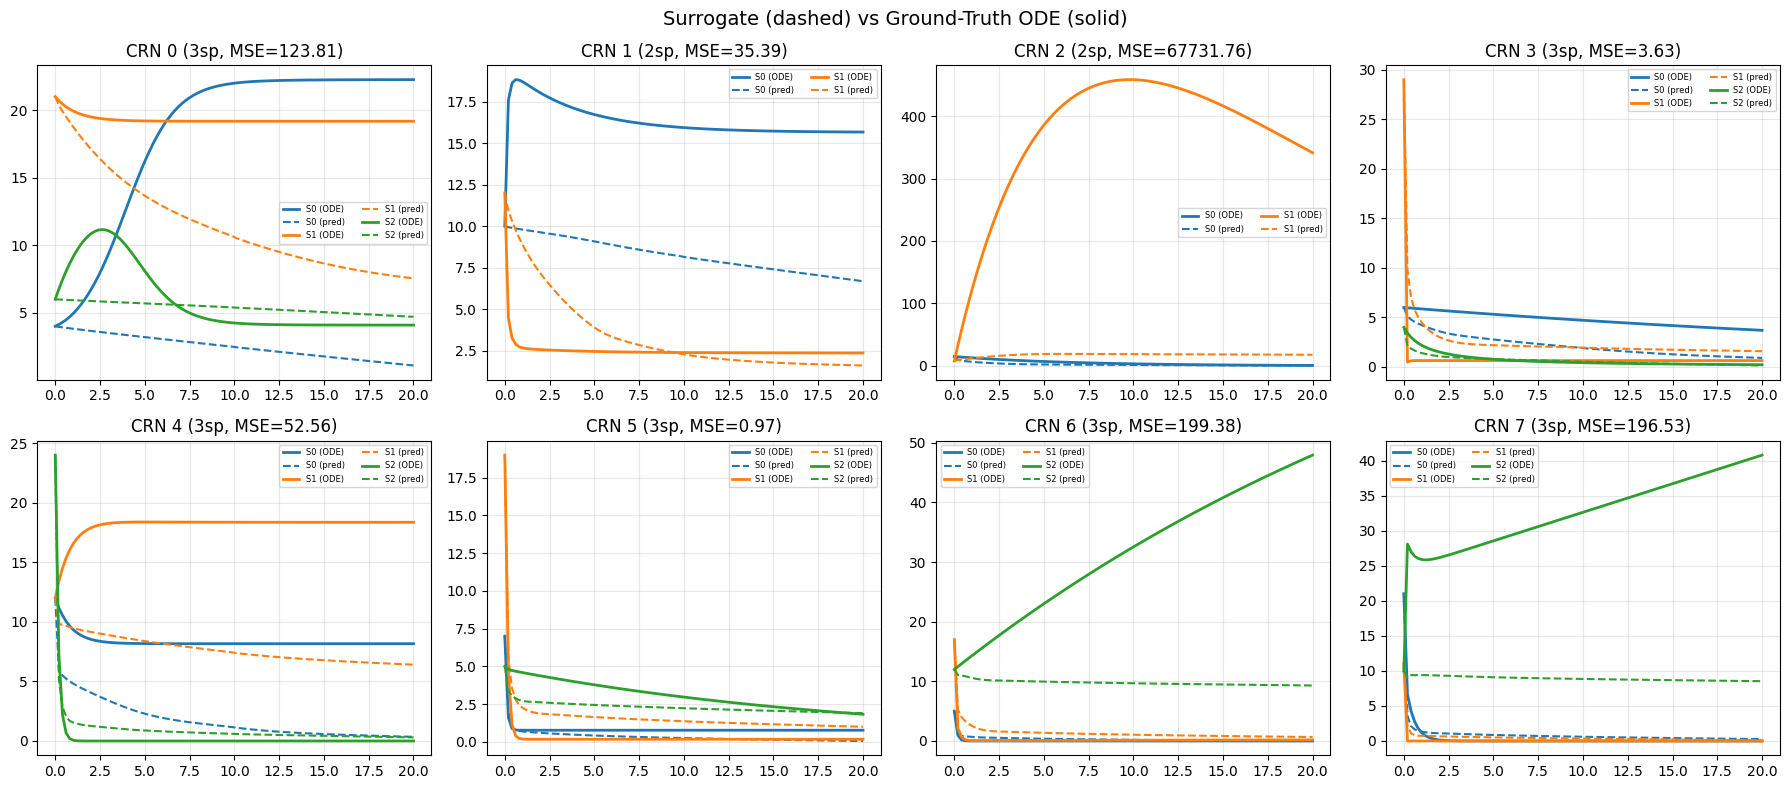


 CRN  n_sp  n_rxn        MSE
------------------------------
   0     3      6   123.8147
   1     2      6    35.3900
   2     2      4 67731.7578
   3     3      4     3.6300
   4     3      4    52.5622
   5     3      7     0.9725
   6     3      6   199.3828
   7     3      6   196.5307


In [22]:
# Compare surrogate vs ground-truth ODE for each test CRN
n_species_sde = cfg.model.max_n_species
results = []

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, (ax, crn) in enumerate(zip(axes.flat, test_crns)):
    init_state = gen.sample_initial_state(crn)
    n_actual = crn.n_species

    # Ground truth ODE
    gt_traj = ode.integrate(crn, init_state, time_grid)
    if gt_traj is None:
        ax.set_title(f"CRN {idx}: blowup")
        continue

    # Surrogate prediction
    crn_repr = crn_to_tensor_repr(crn).to(device)
    with torch.no_grad():
        ctx = encoder(crn_repr)
        # Pad initial state to SDE dimension
        x0_padded = torch.zeros(n_species_sde, device=device)
        x0_padded[:n_actual] = init_state.to(device)
        pred_traj = simulator.solve(
            model, x0_padded, ctx, time_grid.to(device), dt
        )

    pred = pred_traj.states.cpu().numpy()
    gt = gt_traj.numpy()
    t = time_grid.numpy()

    # MSE on active species only
    mse = np.mean((pred[:, :n_actual] - gt[:, :n_actual]) ** 2)
    results.append((crn, mse))

    # Plot
    colors = plt.cm.tab10.colors
    for s in range(n_actual):
        ax.plot(t, gt[:, s], color=colors[s], lw=2, label=f"S{s} (ODE)")
        ax.plot(t, pred[:, s], color=colors[s], lw=1.5, ls="--", label=f"S{s} (pred)")
    ax.set_title(f"CRN {idx} ({n_actual}sp, MSE={mse:.2f})")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

fig.suptitle("Surrogate (dashed) vs Ground-Truth ODE (solid)", fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print(f"\n{'CRN':>4} {'n_sp':>5} {'n_rxn':>6} {'MSE':>10}")
print("-" * 30)
for i, (crn, mse) in enumerate(results):
    print(f"{i:>4} {crn.n_species:>5} {crn.n_reactions:>6} {mse:>10.4f}")

In [ ]:
# Log evaluation to W&B
if USE_WANDB:
    eval_run = wandb.init(
        project=cfg.wandb_project,
        group=cfg.wandb_group,
        job_type="evaluation",
        name=f"{cfg.experiment_name}_eval",
    )
    for i, (crn, mse) in enumerate(results):
        eval_run.log({"test_crn": i, "mse": mse, "n_species": crn.n_species})
    eval_run.log({"trajectory_comparison": wandb.Image(fig)})
    eval_run.finish()

### Test CRN topologies

In [ ]:
from crn_surrogate.data.generation.mass_action_topology import MassActionTopology

for i, (topo, crn) in enumerate(zip(topologies, test_crns)):
    print(f"=== CRN {i} ===")
    print(topo.summary())
    print()

### Training curves (from checkpoint)

In [ ]:
if "train_losses" in ckpt:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    losses = ckpt["train_losses"]
    epochs = range(1, len(losses) + 1)

    axes[0].plot(epochs, losses, color="steelblue", lw=1.5)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train Loss (log)")
    axes[0].set_title("Training Loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, losses, color="steelblue", lw=1.5)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Train Loss")
    axes[1].set_title("Training Loss (linear)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No train_losses in checkpoint (final artifact format may differ).")

## Next steps

Once the deterministic pipeline validates:
1. Switch to stochastic by changing the experiment preset:
   ```
   experiment=mass_action_3s_v7
   ```
2. This will use `NeuralSDE` + `EulerMaruyamaSolver` + `FastSSASimulator` automatically.
3. The encoder weights from the deterministic run can warm-start the stochastic training:
   ```
   resume_weights_only=<path_to_det_checkpoint>
   ```